# Data analysis project of the Marfan Power study as part of the teaching unit Movement Analysis, part 1/2
by Chloé Laignel-Granier

## Data preprocessing and analysis

## Step 1: Import of the raw dataset

In [14]:
# Load dataset
import pandas as pd
import numpy as np
file_path = "data/Marfan.xlsx"
data = pd.read_excel(file_path)

# Display first rows and info about the dataset
print(data.head())
print(data.info())

# Total number of patients
len(data)


   ID        age sexe  weight_kg  height_cm  BMI_kg_cm2  \
0   1  10.529774    M       47.8      162.6   18.079517   
1   2  14.351814    F       43.0      174.0   14.202669   
2   3  10.704997    M       26.0      142.0   12.894267   
3   4  17.393566    F       69.0      185.5   20.052165   
4   5  18.986995    F       54.8      177.0   17.491781   

   6minWT_Distance_traveled_m_before  6minWT_Distance_traveled_m_after  \
0                                660                             737.0   
1                                598                               NaN   
2                                556                             618.0   
3                                588                             692.0   
4                                583                               NaN   

   VO2_SV1__percent_theoretical_before  VO2_SV1__percent_theoretical_after  \
0                            29.918262                           39.958707   
1                            38.742243      

28

The dataset was imported from an Excel file containing clinical and functional data of patients with Marfan syndrome.

There are 28 patients.

## Step 2 : Clean data

In [15]:
# Dropping Unnecessary Variables
data = data.drop(columns=["VO2_SV1__percent_theoretical_before", "VO2_SV1__percent_theoretical_after"], errors="ignore")
# Standardize variable names
data.columns = data.columns.str.lower().str.strip()
data.head()

,id,age,sexe,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,pedsql_totalself_before,pedsql_totalself_after,pedsql_santeself_after,pedsql_emotionself_after,pedsql_relationself_after,pedsql_ecoleself_after,pedsql_psycosocialself_after,pedsql_physiqueself_after
0,1,10.529774,M,47.8,162.6,18.079517,660,737.0,69.565217,75.000000,71.875,70.0,85.0,75.0,76.666667,71.875
1,2,14.351814,F,43.0,174.0,14.202669,598,NaN,86.956522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,10.704997,M,26.0,142.0,12.894267,556,618.0,92.391304,92.391304,96.875,85.0,100.0,85.0,90.000000,96.875
3,4,17.393566,F,69.0,185.5,20.052165,588,692.0,52.173913,57.608696,53.125,55.0,55.0,70.0,60.000000,53.125
4,5,18.986995,F,54.8,177.0,17.491781,583,NaN,76.086957,70.652174,53.125,65.0,75.0,100.0,80.000000,53.125


Variable names were standardized by converting all column names to lowercase and removing leading and trailing spaces to ensure consistency and prevent errors during data processing.

In [16]:
# Data quality checks

from IPython.display import display, Markdown

display(Markdown("### Missing Data"))
missing_table = data.isna().sum().to_frame(name="Missing values")
display(missing_table)

display(Markdown("### Duplicate Observations"))
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

display(Markdown("### Descriptive Statistics"))
display(data.describe().round(1))

### Missing Data

,Missing values
id,0
age,0
sexe,0
weight_kg,0
height_cm,0
bmi_kg_cm2,0
6minwt_distance_traveled_m_before,0
6minwt_distance_traveled_m_after,8
pedsql_totalself_before,0
pedsql_totalself_after,6


### Duplicate Observations

Number of duplicate rows: 0


### Descriptive Statistics

,id,age,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,pedsql_totalself_before,pedsql_totalself_after,pedsql_santeself_after,pedsql_emotionself_after,pedsql_relationself_after,pedsql_ecoleself_after,pedsql_psycosocialself_after,pedsql_physiqueself_after
count,28.0,28.0,28.0,28.0,28.0,28.0,20.0,28.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0
mean,14.5,12.8,46.9,166.1,16.4,583.1,619.2,71.7,78.9,80.0,76.8,83.9,74.3,78.3,80.0
std,8.2,3.7,16.8,19.5,3.4,49.0,79.9,15.1,11.2,15.5,15.9,12.6,15.9,11.8,15.5
min,1.0,7.2,22.0,134.0,12.1,450.0,460.0,34.8,57.6,53.1,40.0,55.0,40.0,56.7,53.1
25%,7.8,10.3,31.2,149.2,13.6,559.0,582.5,64.7,72.0,66.4,66.2,76.2,62.5,72.1,66.4
50%,14.5,12.5,48.4,167.5,15.0,588.0,610.0,69.6,77.7,82.8,77.5,80.0,77.5,79.2,82.8
75%,21.2,15.5,59.4,182.2,18.9,621.2,684.5,84.0,87.8,93.0,90.0,97.5,85.0,86.7,93.0
max,28.0,19.9,82.0,199.0,24.5,660.0,744.0,93.5,97.8,100.0,100.0,100.0,100.0,98.3,100.0


Data quality was assessed by examining missing values, duplicate observations, and descriptive statistics. 

Missing data were quantified for each variable, duplicate entries were checked, and summary statistics were used to identify potential outliers and inconsistencies.

## Step 3 : Separate the analyzed and excluded patients

In [17]:
# Define key variables for analysis
cols_all = [
    "6minwt_distance_traveled_m_before",
    "6minwt_distance_traveled_m_after",
    "pedsql_totalself_after",
    "pedsql_santeself_after",
    "pedsql_relationself_after",
    "pedsql_ecoleself_after",
    "pedsql_psycosocialself_after",  
    "pedsql_physiqueself_after"
]

# Analysable patients (no missing data)
data_inclus = data.dropna(subset=cols_all)

# Excluded patients
data_exclus = data[data[cols_all].isna().any(axis=1)]

# Verification
print("Total patients:", len(data))
print("Included:", len(data_inclus))
print("Excluded:", len(data_exclus))

# Check excluded patients
print(data_exclus[cols_all])

Total patients: 28
Included: 20
Excluded: 8
    6minwt_distance_traveled_m_before  6minwt_distance_traveled_m_after  \
1                                 598                               NaN   
4                                 583                               NaN   
6                                 635                               NaN   
11                                634                               NaN   
15                                593                               NaN   
16                                568                               NaN   
24                                580                               NaN   
26                                588                               NaN   

    pedsql_totalself_after  pedsql_santeself_after  pedsql_relationself_after  \
1                      NaN                     NaN                        NaN   
4                70.652174                  53.125                       75.0   
6                      NaN           

Key outcome measures included the 6-minute walk test (TM6M) and PedsQL quality of life scores.

Patients with missing data for the main outcome variables (6 m gait test or PedsQL test) were excluded from the primary analysis.

## Step 4 : Transformation to Long Format

In [18]:
# Transform the data to long format for distance traveled
distance_long = pd.melt(
    data_inclus,
    id_vars=["id"],
    value_vars=["6minwt_distance_traveled_m_before","6minwt_distance_traveled_m_after"],
    var_name="time",
    value_name="distance"
)

# Simplify the time variable
distance_long["time"] = distance_long["time"].map({
     "6minwt_distance_traveled_m_before": "T-3",
     "6minwt_distance_traveled_m_after": "T+6"
 })
print(distance_long)

    id time  distance
0    1  T-3     660.0
1    3  T-3     556.0
2    4  T-3     588.0
3    6  T-3     635.0
4    8  T-3     640.0
5    9  T-3     593.0
6   10  T-3     551.0
7   11  T-3     516.0
8   13  T-3     625.0
9   14  T-3     526.0
10  15  T-3     608.0
11  18  T-3     620.0
12  19  T-3     495.0
13  20  T-3     650.0
14  21  T-3     580.0
15  22  T-3     560.0
16  23  T-3     450.0
17  24  T-3     560.0
18  26  T-3     535.0
19  28  T-3     600.0
20   1  T+6     737.0
21   3  T+6     618.0
22   4  T+6     692.0
23   6  T+6     697.0
24   8  T+6     598.0
25   9  T+6     682.0
26  10  T+6     744.0
27  11  T+6     682.0
28  13  T+6     575.0
29  14  T+6     585.0
30  15  T+6     605.0
31  18  T+6     615.0
32  19  T+6     490.0
33  20  T+6     725.0
34  21  T+6     540.0
35  22  T+6     625.0
36  23  T+6     460.0
37  24  T+6     530.0
38  26  T+6     590.0
39  28  T+6     595.0


Data were converted to long format for visualization and paired analysis.

## Step 5: Export data_clean to R

In [19]:
# Export data for further analysis
data_inclus.to_excel("data/data_clean.xlsx", index=False)
data_exclus.to_excel("data/data_excluded.xlsx", index=False)

## Step 6: Analysis of 6MWT — Calculation of Changes and Data Visualization

### Calculation of change (6mwt)

In [20]:
# Compute change (delta)
data_inclus["delta_6mwt"] = data_inclus["6minwt_distance_traveled_m_after"] - data_inclus["6minwt_distance_traveled_m_before"]
print(data_inclus[["id", "delta_6mwt"]])

    id  delta_6mwt
0    1        77.0
2    3        62.0
3    4       104.0
5    6        62.0
7    8       -42.0
8    9        89.0
9   10       193.0
10  11       166.0
12  13       -50.0
13  14        59.0
14  15        -3.0
17  18        -5.0
18  19        -5.0
19  20        75.0
20  21       -40.0
21  22        65.0
22  23        10.0
23  24       -30.0
25  26        55.0
27  28        -5.0


Individual changes in 6MWT distance were calculated as the difference between post- and pre-intervention values.

### Data visualization

### Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention

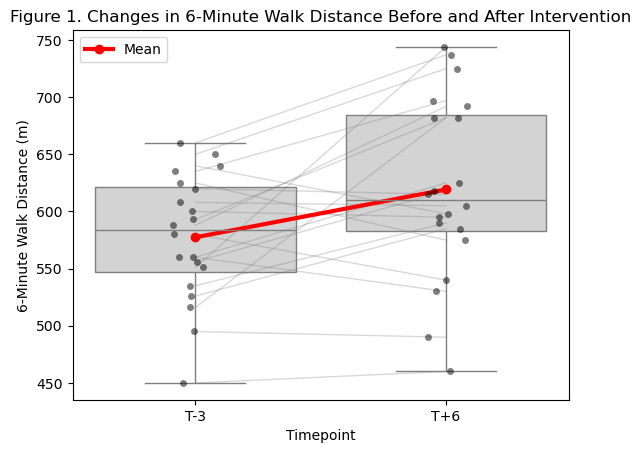

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Boxplot showing the distribution at each timepoint
sns.boxplot(
    data=distance_long,
    x="time",
    y="distance",
    color="lightgrey"
)

# Individual data points
sns.stripplot(
    data=distance_long,
    x="time",
    y="distance",
    color="black",
    alpha=0.5,
    jitter=True
)

# Paired lines for each patient (before → after)
for i in range(len(data_inclus)):
    plt.plot(
        ["T-3", "T+6"],
        [
            data_inclus["6minwt_distance_traveled_m_before"].iloc[i],
            data_inclus["6minwt_distance_traveled_m_after"].iloc[i]
        ],
        color="grey",
        alpha=0.3,
        linewidth=1
    )

# Compute mean values at each timepoint
mean_before = data_inclus["6minwt_distance_traveled_m_before"].mean()
mean_after = data_inclus["6minwt_distance_traveled_m_after"].mean()

# Add mean line (highlighted)
plt.plot(
    ["T-3", "T+6"],
    [mean_before, mean_after],
    color="red",
    linewidth=3,
    marker="o",
    label="Mean"
)

# Labels and title
plt.xlabel("Timepoint")
plt.ylabel("6-Minute Walk Distance (m)")
plt.title("Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Figure_1_Changes_in_6MWT_Before_After.pdf",
    bbox_inches="tight"
)

# Display the plot
plt.show()

### Interpretation : Figure 1. Changes in 6-Minute Walk Distance Before and After Intervention

Data were visualized using boxplots combined with individual data points and paired lines to illustrate changes in 6-minute walk distance between baseline (T−3) and post-intervention (T+6). This visualization was performed as an exploratory step prior to statistical analysis in R.

The boxplots show a shift toward higher values at T+6 compared to T−3, suggesting an overall improvement in functional capacity following the intervention. This trend is supported by the upward trajectory of most individual paired lines, indicating that the majority of patients experienced an increase in walking distance.

However, some variability is observed, with a few patients showing little or no improvement, or even a decrease in performance. The dispersion of the data highlights inter-individual differences in response to the intervention.

The mean values, represented by the red line, further emphasize the overall increase in 6-minute walk distance from baseline to post-intervention.

Overall, this figure provides an initial visual assessment of paired changes and supports the subsequent statistical analysis, indicating a general improvement in functional capacity after the intervention.

###  Figure 2. Distribution of Changes in 6-Minute Walk Distance

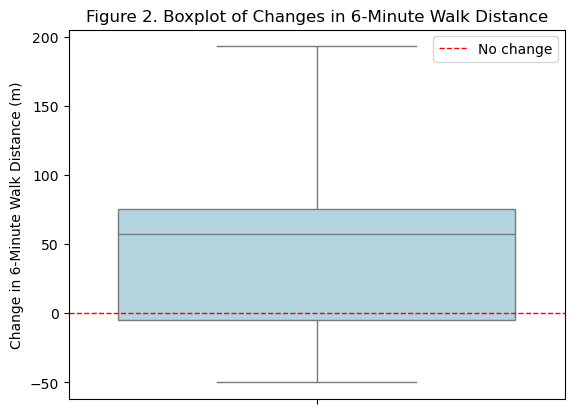

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot showing the distribution of individual changes (delta)
sns.boxplot(
    y=data_inclus["delta_6mwt"],
    color="lightblue"
)

# Add reference line at zero (no change)
plt.axhline(
    0,
    linestyle="--",
    color="red",
    linewidth=1,
    label="No change"
)

# Labels and title
plt.ylabel("Change in 6-Minute Walk Distance (m)")
plt.title("Figure 2. Boxplot of Changes in 6-Minute Walk Distance")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Figure_2_Boxplot_of_Changes_in_6-Minute_Walk_Distance.pdf",
    bbox_inches="tight"
)

# Display the plot
plt.show()

### Figure_3_Histogram_of_Individual_Changes_in_the_6-Minute_Walk_Test

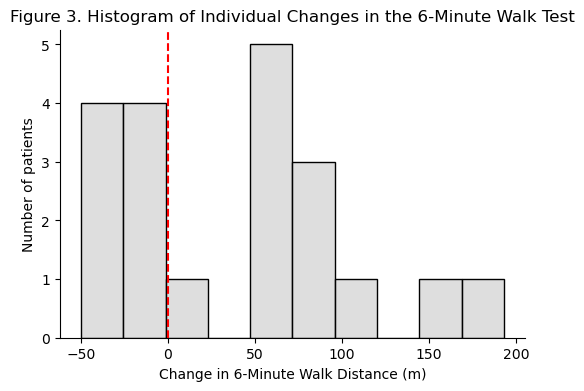

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output folder if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Plot
plt.figure(figsize=(6, 4))

sns.histplot(data=data_inclus, x="delta_6mwt", bins=10, color="lightgrey", edgecolor="black")

# Vertical line at 0
plt.axvline(x=0, linestyle="--", color="red")

# Labels and title
plt.xlabel("Change in 6-Minute Walk Distance (m)")
plt.ylabel("Number of patients")
plt.title("Figure 3. Histogram of Individual Changes in the 6-Minute Walk Test")

# Minimal theme
sns.despine()

# Save as PDF
plt.savefig("figures/Figure_3_Histogram_of_Individual_Changes_in_the_6-Minute_Walk_Test.pdf", bbox_inches="tight")

# Show plot
plt.show()

### Interpretation: Figures 2 and 3 — Distribution of Changes in 6-Minute Walk Distance

The distribution of individual changes in 6-minute walk distance (Δ6MWT) was explored using a boxplot (Figure 2) and a histogram (Figure 3) prior to statistical analysis.

Both visualizations indicate that the majority of patients experienced an improvement, as reflected by a median above zero and a predominance of positive values. However, some variability is observed, with a few patients showing no improvement or a decrease in performance.

The histogram further suggests a right-skewed distribution, indicating that some patients achieved larger improvements.

Overall, these exploratory analyses support the use of a non-parametric statistical approach.

### Table 1. Distribution and changes in 6-minute walk distance

In [24]:
import pandas as pd 
import matplotlib.pyplot as plt

# Format median[IQR]
summary_table = distance_long.groupby("time")["distance"].agg(
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Create formatted column
summary_table["Median [IQR]"] = (
    summary_table["Median"].round(1).astype(str) + " [" +
    summary_table["Q1"].round(1).astype(str) + "–" +
    summary_table["Q3"].round(1).astype(str) + "]"
)

# Keep only useful column
summary_table = summary_table[["Median [IQR]"]]

# Rename index
summary_table.index = ["T-3", "T+6"]

# delta median[IQR]
delta_median = data_inclus["delta_6mwt"].median()
delta_q1 = data_inclus["delta_6mwt"].quantile(0.25)
delta_q3 = data_inclus["delta_6mwt"].quantile(0.75)

delta_summary = pd.DataFrame({
    "Median [IQR]": [
        f"{round(delta_median,1)} [{round(delta_q1,1)}–{round(delta_q3,1)}]"
    ]
}, index=["Δ (T+6 – T-3)"])

# Delta summary 
improvement = (data_inclus["delta_6mwt"] > 0).sum()
no_change = (data_inclus["delta_6mwt"] == 0).sum()
decrease = (data_inclus["delta_6mwt"] < 0).sum()

total = len(data_inclus)

delta_table = pd.DataFrame({
    "Change (n, %)": [
        f"{improvement} ({round(improvement/total*100,1)}%)",
        f"{no_change} ({round(no_change/total*100,1)}%)",
        f"{decrease} ({round(decrease/total*100,1)}%)"
    ]
}, index=["Improved", "No change", "Decreased"])


# Final table
final_table = pd.concat([summary_table, delta_summary, delta_table])


# Export PDF
fig, ax = plt.subplots(figsize=(6,4))
ax.axis('off')

table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    rowLabels=final_table.index,
    loc='center'
)

# Title
plt.title(
    "Table 1. Distribution and changes in 6-minute walk distance",
    fontsize=12,
    pad=20
)

plt.savefig("figures/Table_1_Distribution_and_changes_in_6-minute_walk_distance.pdf", bbox_inches="tight")
plt.close()

from IPython.display import display

display(final_table.style.set_caption(
    "Table 1. Distribution and changes in 6-minute walk distance"
))

,Median [IQR],"Change (n, %)"
T-3,610.0 [582.5–684.5],nan
T+6,584.0 [547.0–621.2],nan
Δ (T+6 – T-3),57.0 [-5.0–75.5],nan
Improved,nan,12 (60.0%)
No change,nan,0 (0.0%)
Decreased,nan,8 (40.0%)


### Interpretation : Table 1. Distribution and changes in 6-minute walk distance

Descriptive statistics are presented as median [interquartile range] for each timepoint.

At baseline (T−3), the median 6-minute walk distance was 610.0 m [582.5–684.5], compared to 584.0 m [547.0–621.2] post-intervention (T+6). The median individual change (Δ) was 57.0 m [−5.0–75.5], indicating an overall improvement, although with some variability across patients.

Individual changes are further summarized as the number and percentage of patients who improved, remained stable, or decreased following the intervention. A total of 12 out of 20 patients (60.0%) showed an improvement, while 8 patients (40.0%) exhibited a decrease, and none remained stable.

Overall, this table provides a concise summary of both central tendencies at each timepoint and the distribution of individual changes, allowing an initial interpretation of the intervention effect prior to formal statistical testing.

## Conclusion

Cleaned datasets were exported for statistical analysis in R.

The primary analysis was conducted on patients with complete data, while excluded patients were analyzed separately to assess potential selection bias.

The 6-minute walk test (6MWT) was defined as the primary outcome of the study.

An initial exploratory analysis was performed in Python to visualize and describe the data prior to statistical testing. A boxplot combined with individual paired trajectories (Figure 1) was used to illustrate changes in 6MWT distance between baseline and post-intervention, suggesting an overall improvement in functional capacity.

The distribution of individual changes was further explored using a boxplot of Δ6MWT (Figure 2), allowing identification of the direction and variability of changes, and providing a visual distinction between improvement and decline.

Descriptive statistics (Table 1) were calculated and presented as median [IQR], along with the number and percentage of patients who improved, remained stable, or decreased, offering a concise summary of both central tendency and individual responses prior to statistical analysis.

Statistical analyses were then performed using R, including paired comparisons of pre- and post-intervention values using appropriate tests.

To ensure clarity of the analyses, no formal statistical analysis was performed on VAT.

However, an exploratory correlation analysis between 6MWT and PedsQL scores was conducted to assess the relationship between functional capacity and quality of life.